# Cavity Loss Effects & Reoptimization

This first script takes a fully optimized run and compares it the outcome of individual cavity failures. Cavity loss leads to particle losses. This scraping can counterintuitively lead to decreases in emittance, because those particles on the outside of the envelope are lost. Total energy at the end of the beamline is not heavily affected by a single cavity loss.

The following script shows number of particles lost as a function of cavity loss (for 10k macro particles). Earlier cavity failures have larger particle loss consequences.

 This indicates that we should weight particle loss much more heavily than emittance growth in a re-optimization procedure.

Successfully saved plot to 'emittance_xy_z_energy_numeric_baseline_plot.png'.


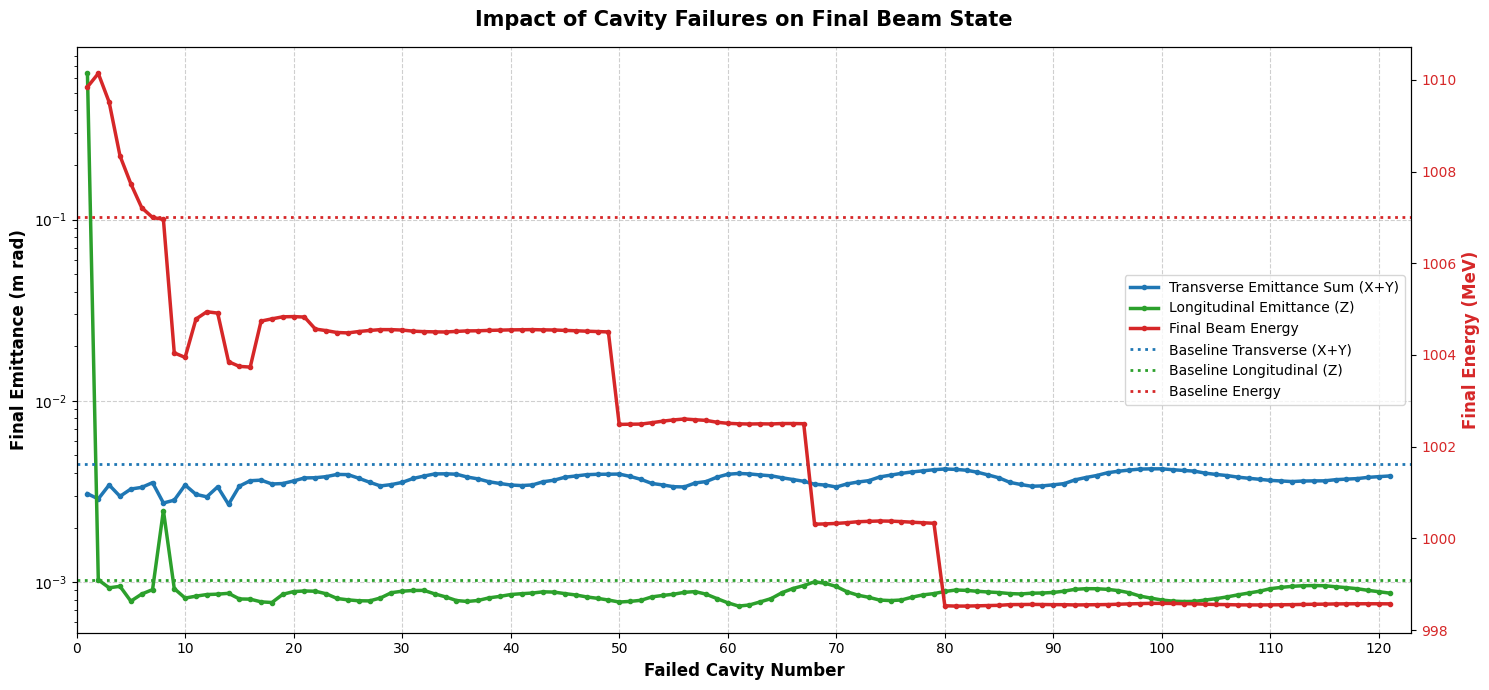

In [203]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def extract_from_stat(stat_file):
    """Parses an OPAL .stat file to extract final energy, transverse, and longitudinal emittance."""
    col_names = []
    in_column = False
    
    with open(stat_file, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        line_stripped = line.strip()
        if line_stripped.startswith('&column'):
            in_column = True
        elif in_column and line_stripped.startswith('name='):
            name = line_stripped.split('=')[1].strip(',"\'').lower()
            col_names.append(name)
        elif line_stripped.startswith('&end') and in_column:
            in_column = False

    expected_cols = len(col_names)
    data_rows = []
    
    for line in lines:
        parts = line.split()
        if len(parts) == expected_cols:
            try:
                data_rows.append([float(x) for x in parts])
            except ValueError:
                pass
                
    if not data_rows: 
        return None
        
    last_row = data_rows[-1]
    
    try:
        idx_eps_x = col_names.index('rms_x')
        idx_eps_y = col_names.index('rms_y')
        idx_eps_z = col_names.index('rms_s')
        idx_energy = col_names.index('energy')
    except ValueError as e:
        print(f"Missing expected columns in {stat_file}: {e}")
        return None
        
    return {
        'emit_sum_xy': last_row[idx_eps_x] + last_row[idx_eps_y],
        'emit_z': last_row[idx_eps_z],
        'final_energy': last_row[idx_energy]
    }

def plot_emittance_and_energy(baseline_file=None):
    # 1. Find all failure stat files
    stat_files = glob.glob("fail_CAV*.stat")
    if not stat_files:
        print("No 'fail_CAV*.stat' files found. Ensure you are in the correct directory.")
        return

    results = []
    for f in stat_files:
        # Extract the integer cavity number from 'fail_CAV001.stat'
        num_str = f.replace('fail_CAV', '').replace('.stat', '')
        try:
            cav_num = int(num_str)
        except ValueError:
            continue
            
        data = extract_from_stat(f)
        if data:
            data['Cavity_Num'] = cav_num
            results.append(data)
            
    # 2. Build and sort the DataFrame by integer cavity number
    df = pd.DataFrame(results)
    df = df.sort_values('Cavity_Num').reset_index(drop=True)
    
    if df.empty:
        print("No valid data could be extracted.")
        return

    # 3. Extract baseline data if provided
    baseline_data = None
    if baseline_file:
        if os.path.exists(baseline_file):
            baseline_data = extract_from_stat(baseline_file)
            if not baseline_data:
                print(f"Warning: Could not parse baseline data from {baseline_file}")
        else:
            print(f"Warning: Baseline file '{baseline_file}' not found.")

    # 4. Setup the Dual-Axis Plot
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # --- Plot Transverse and Longitudinal Emittance on Left Y-Axis ---
    line1 = ax1.plot(
        df['Cavity_Num'], df['emit_sum_xy'], 
        marker='.', linestyle='-', color='#1f77b4', 
        linewidth=2.5, markersize=6, label='Transverse Emittance Sum (X+Y)'
    )
    
    line2 = ax1.plot(
        df['Cavity_Num'], df['emit_z'], 
        marker='.', linestyle='-', color='#2ca02c', 
        linewidth=2.5, markersize=6, label='Longitudinal Emittance (Z)'
    )
    
    ax1.set_xlabel('Failed Cavity Number', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Final Emittance (m rad)', fontsize=12, fontweight='bold', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax1.set_yscale('log')
    
    # Enforce x-axis ticks every 10 units
    ax1.xaxis.set_major_locator(MultipleLocator(10))
    ax1.set_xlim(left=0, right=df['Cavity_Num'].max() + 2)

    # --- Plot Energy on Right Y-Axis ---
    ax2 = ax1.twinx()
    line3 = ax2.plot(
        df['Cavity_Num'], df['final_energy'], 
        marker='.', linestyle='-', color='#d62728', 
        linewidth=2.5, markersize=6, label='Final Beam Energy'
    )
    
    ax2.set_ylabel('Final Energy (MeV)', fontsize=12, fontweight='bold', color='#d62728')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    #ax2.set_yscale('log')
    lines = line1 + line2 + line3

    # --- Plot Baseline Dotted Lines (if available) ---
    if baseline_data:
        base_xy = ax1.axhline(baseline_data['emit_sum_xy'], color='#1f77b4', linestyle=':', linewidth=2, label='Baseline Transverse (X+Y)')
        base_z = ax1.axhline(baseline_data['emit_z'], color='#2ca02c', linestyle=':', linewidth=2, label='Baseline Longitudinal (Z)')
        base_e = ax2.axhline(baseline_data['final_energy'], color='#d62728', linestyle=':', linewidth=2, label='Baseline Energy')
        
        # Add baseline items to the legend list
        lines.extend([base_xy, base_z, base_e])

    # 5. Combine Legends and Format
    labels = [l.get_label() for l in lines]
    
    ax1.legend(lines, labels, loc='center right')#, bbox_to_anchor=(1.1, 0.5))
    
    plt.title('Impact of Cavity Failures on Final Beam State', fontsize=15, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    output_filename = 'emittance_xy_z_energy_numeric_baseline_plot.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully saved plot to '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    # To use a baseline, add your unperturbed stat file here, e.g.:
    # plot_emittance_and_energy(baseline_file="nominal_run.stat")
    plot_emittance_and_energy(baseline_file="/home/vagrant/jupyter/github/rsnewton/opal/20260710_25mA/opal.stat")

Successfully saved plot to 'corrected_particle_loss_plot.png'. Target ZSTOP detected as ~148.35 m.


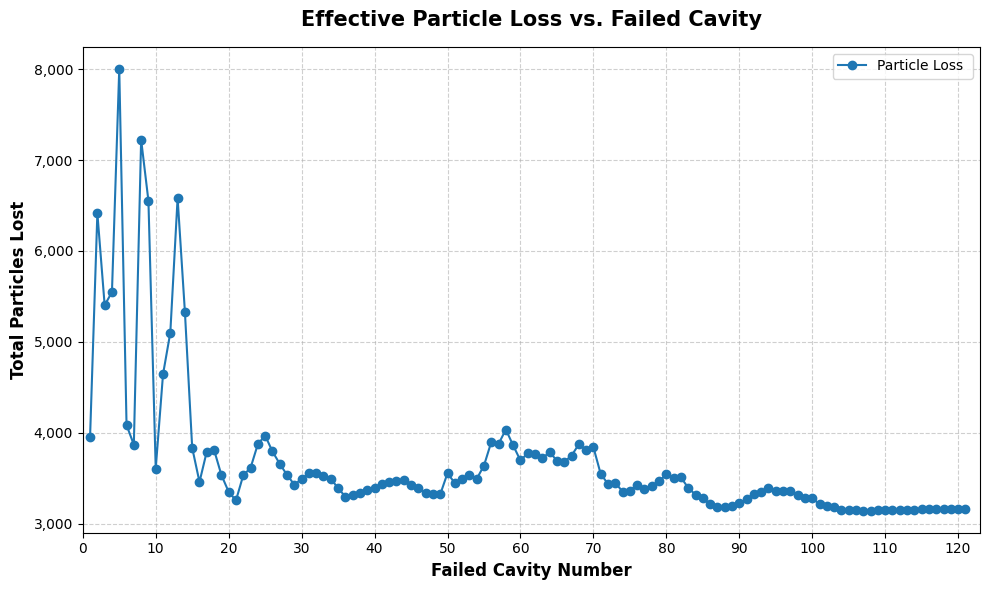

In [208]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

def extract_corrected_loss(stat_file):
    """Parses an OPAL .stat file to calculate total particle loss, correcting for early termination."""
    col_names = []
    in_column = False
    
    with open(stat_file, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        line_stripped = line.strip()
        if line_stripped.startswith('&column'):
            in_column = True
        elif in_column and line_stripped.startswith('name='):
            name = line_stripped.split('=')[1].strip(',"\'').lower()
            col_names.append(name)
        elif line_stripped.startswith('&end') and in_column:
            in_column = False

    expected_cols = len(col_names)
    data_rows = []
    
    for line in lines:
        parts = line.split()
        if len(parts) == expected_cols:
            try:
                data_rows.append([float(x) for x in parts])
            except ValueError:
                pass
                
    if not data_rows: 
        return None
        
    try:
        idx_particles = col_names.index('numparticles')
        idx_s = col_names.index('s')
    except ValueError:
        return None
        
    initial_particles = data_rows[0][idx_particles]
    final_particles = data_rows[-1][idx_particles]
    final_s = data_rows[-1][idx_s]
    
    return {
        'Initial_Particles': initial_particles,
        'Stat_Loss': initial_particles - final_particles,
        'Final_S': final_s
    }

def plot_corrected_particle_loss():
    stat_files = glob.glob("fail_CAV*.stat")
    if not stat_files:
        print("No 'fail_CAV*.stat' files found.")
        return

    results = []
    for f in stat_files:
        num_str = f.replace('fail_CAV', '').replace('.stat', '')
        try:
            cav_num = int(num_str)
        except ValueError:
            continue
            
        data = extract_corrected_loss(f)
        if data is not None:
            data['Cavity_Num'] = cav_num
            results.append(data)
            
    df = pd.DataFrame(results)
    df = df.sort_values('Cavity_Num').reset_index(drop=True)
    
    if df.empty:
        return

    # 1. Determine the intended length of the accelerator
    # We assume the maximum distance achieved by any beam is the target ZSTOP
    target_zstop = df['Final_S'].max()
    
    # We define "early termination" as stopping more than 0.1 meters short of ZSTOP
    distance_tolerance = 0.1 

    # 2. Correct the Particle Loss
    # If it stopped early, the beam didn't make it. Treat it as 100% lost.
    df['Corrected_Loss'] = df.apply(
        lambda row: row['Initial_Particles'] if row['Final_S'] < (target_zstop - distance_tolerance) else row['Stat_Loss'],
        axis=1
    )

    # 3. Setup the Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the Corrected Loss
#    ax.plot(
#        df['Cavity_Num'], 
#        df['Corrected_Loss'], 
#        marker='o', 
#        linestyle='-', 
#        color='#d62728', 
#        linewidth=2, 
#        markersize=6,
#        label='Effective Particles Lost (Corrected)'
#    )

    # Plot the original (flawed) loss as a faded line for comparison
    ax.plot(
        df['Cavity_Num'], 
        df['Stat_Loss'], 
        marker='o', 
        #linestyle=None, 
        #color='#7f7f7f', 
        #linewidth=1.5, 
        #alpha=0.6,
        label='Particle Loss '
    )

    ax.set_title('Effective Particle Loss vs. Failed Cavity', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Failed Cavity Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Particles Lost', fontsize=12, fontweight='bold')
    
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_xlim(left=0, right=df['Cavity_Num'].max() + 2)
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    output_filename = 'corrected_particle_loss_plot.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully saved plot to '{output_filename}'. Target ZSTOP detected as ~{target_zstop:.2f} m.")
    plt.show()

if __name__ == "__main__":
    plot_corrected_particle_loss()

# Optimization History and tracking

While the optimization script is running, and after the optimization is complete, this will track the progress of the penalty score through BOBYQA optimization

Successfully saved plot to 'convergence_with_params.png'.


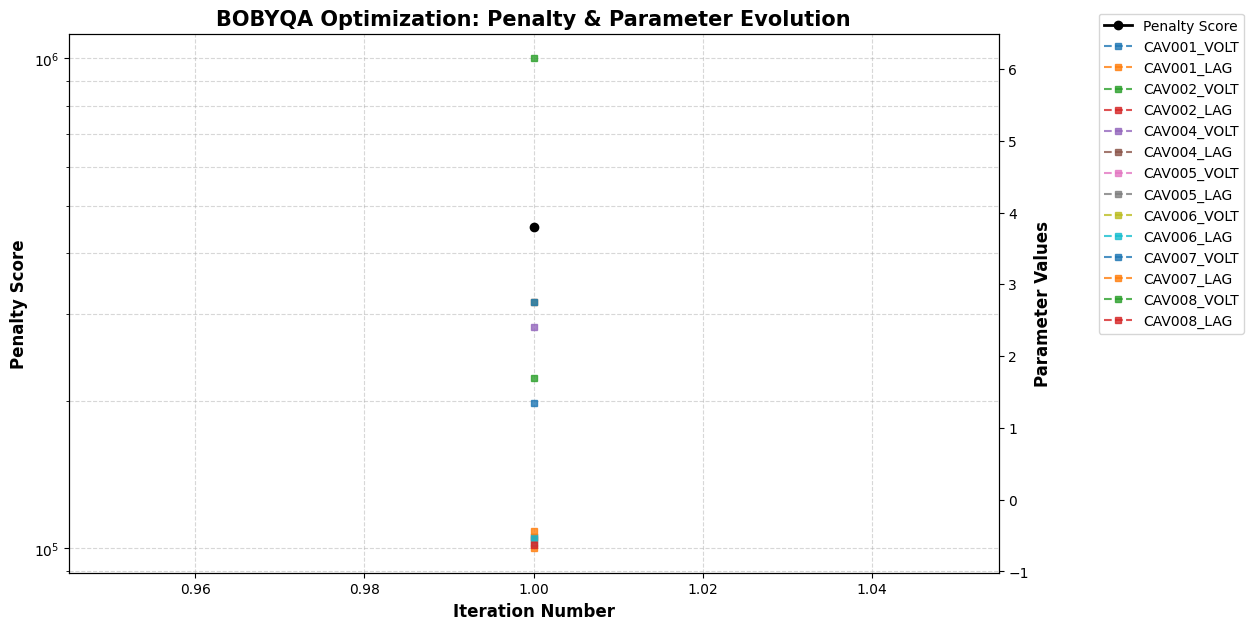

In [340]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_optimization_history(csv_filename="optimization_history_CAV003.csv"):
    """
    Reads the optimization history CSV and plots the penalty score on the left y-axis,
    and the individual parameter evolutions on the right y-axis.
    """
    try:
        # 1. Load the data
        df = pd.read_csv(csv_filename)
        
        if 'Iteration' not in df.columns or 'Penalty' not in df.columns:
            print(f"Error: '{csv_filename}' must contain 'Iteration' and 'Penalty' columns.")
            return

        # Identify all parameter columns (everything except Iteration and Penalty)
        param_cols = [col for col in df.columns if col not in ['Iteration', 'Penalty']]

        # 2. Set up the figure and primary axis (ax1)
        fig, ax1 = plt.subplots(figsize=(12, 7))
        
        # Plot Penalty on the left axis
        line1 = ax1.plot(
            df['Iteration'], 
            df['Penalty'], 
            marker='o', 
            linestyle='-', 
            color='black', 
            markersize=6,
            linewidth=2,
            label='Penalty Score'
        )
        
        ax1.set_xlabel('Iteration Number', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Penalty Score', fontsize=12, fontweight='bold')
        ax1.tick_params(axis='y')
        
        # Automatically use a log scale if there are massive penalty spikes
        if df['Penalty'].max() > 100 * df['Penalty'].min() and df['Penalty'].min() > 0:
            ax1.set_yscale('log')
            ax1.set_ylabel('Penalty Score (Log Scale)', fontsize=12, fontweight='bold')

        # 3. Set up the secondary axis (ax2)
        ax2 = ax1.twinx()
        ax2.set_ylabel('Parameter Values', fontsize=12, fontweight='bold')
        
        # Plot each parameter on the right axis
        param_lines = []
        for col in param_cols:
            line = ax2.plot(
                df['Iteration'], 
                df[col], 
                marker='s',      # Square markers for parameters
                markersize=4,
                linestyle='--',  # Dashed lines to differentiate from penalty
                alpha=0.8,
                label=col
            )
            param_lines.extend(line)

        # 4. Format Legends and Grid
        # Combine legends from both axes into one cohesive box
        lines = line1 + param_lines
        labels = [l.get_label() for l in lines]
        
        # Place the legend outside the plot to avoid covering data
        ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(1.1, 1.05))
        ax1.set_yscale('log')
        ax1.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.title('BOBYQA Optimization: Penalty & Parameter Evolution', fontsize=15, fontweight='bold')
        
        # 5. Save and display
        # Use bbox_inches='tight' so the external legend isn't cut off
        output_image = 'convergence_with_params.png'
        plt.savefig(output_image, dpi=300, bbox_inches='tight')
        print(f"Successfully saved plot to '{output_image}'.")
        
        plt.show()

    except FileNotFoundError:
        print(f"Error: Could not find '{csv_filename}'. Ensure the optimization has run first.")
    except Exception as e:
        print(f"An unexpected error occurred while plotting: {e}")

if __name__ == "__main__":
    plot_optimization_history()

# Comparing the results of a single optimization to the initial conditions

Plot saved successfully as 'emittance_comparison.png'.


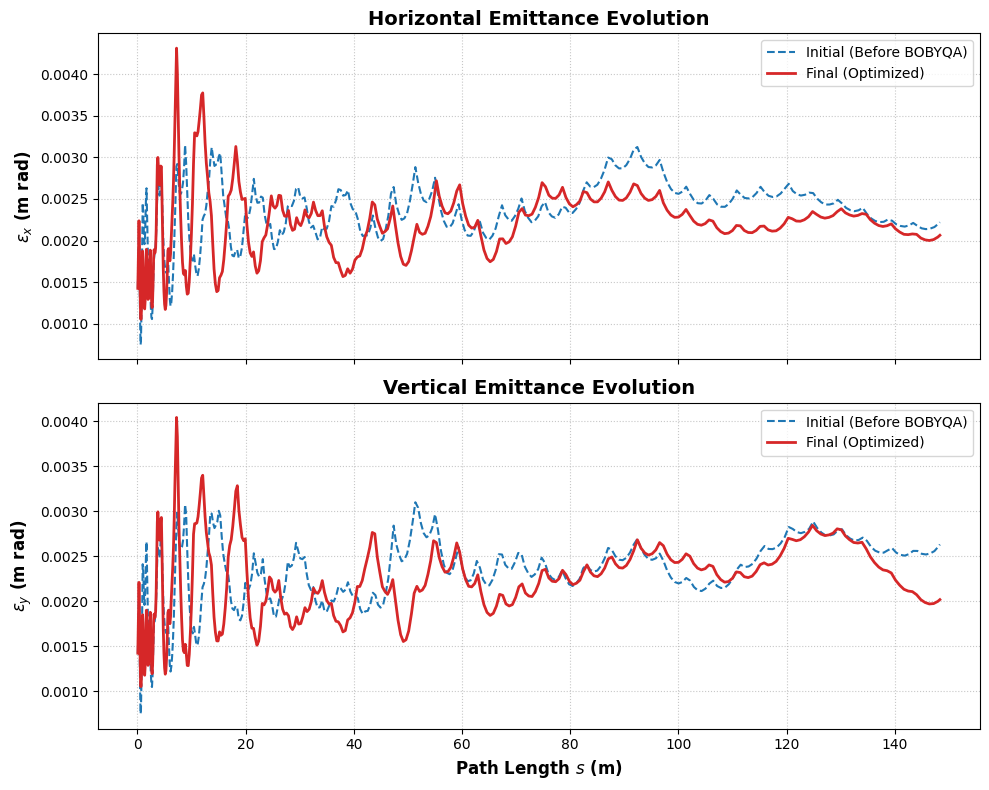

In [5]:
import os
import matplotlib.pyplot as plt

def parse_stat_file(stat_file):
    """
    Parses an OPAL .stat file and returns lists for s, eps_x, and eps_y.
    """
    if not os.path.exists(stat_file):
        raise FileNotFoundError(f"Could not find '{stat_file}'.")

    col_names = []
    in_column = False
    
    with open(stat_file, 'r') as f:
        lines = f.readlines()
        
    # 1. Parse Header
    for line in lines:
        line_stripped = line.strip()
        if line_stripped.startswith('&column'):
            in_column = True
        elif in_column and line_stripped.startswith('name='):
            name = line_stripped.split('=')[1].strip(',"\'').lower()
            col_names.append(name)
        elif line_stripped.startswith('&end') and in_column:
            in_column = False

    expected_cols = len(col_names)
    
    try:
        idx_s = col_names.index('s')
        idx_eps_x = col_names.index('rms_x')
        idx_eps_y = col_names.index('rms_y')
    except ValueError as e:
        raise ValueError(f"Missing required column in {stat_file}: {e}")

    # 2. Extract Data
    s_vals, eps_x_vals, eps_y_vals = [], [], []
    
    for line in lines:
        parts = line.split()
        if len(parts) == expected_cols:
            try:
                row_floats = [float(x) for x in parts]
                s_vals.append(row_floats[idx_s])
                eps_x_vals.append(row_floats[idx_eps_x])
                eps_y_vals.append(row_floats[idx_eps_y])
            except ValueError:
                pass # Ignore non-numeric lines

    return s_vals, eps_x_vals, eps_y_vals

def plot_emittance_comparison(file_initial, file_final):
    """
    Plots eps_x and eps_y from two different .stat files.
    """
    try:
        s_init, eps_x_init, eps_y_init = parse_stat_file(file_initial)
        s_final, eps_x_final, eps_y_final = parse_stat_file(file_final)
    except Exception as e:
        print(f"Error loading data: {e}")
        return

    # Create figure with two subplots (one for X, one for Y)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot X Emittance
    ax1.plot(s_init, eps_x_init, label='Initial (Before BOBYQA)', color='#1f77b4', linestyle='--')
    ax1.plot(s_final, eps_x_final, label='Final (Optimized)', color='#d62728', linewidth=2)
    ax1.set_ylabel(r'$\epsilon_x$ (m rad)', fontsize=12, fontweight='bold')
    ax1.set_title('Horizontal Emittance Evolution', fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend()

    # Plot Y Emittance
    ax2.plot(s_init, eps_y_init, label='Initial (Before BOBYQA)', color='#1f77b4', linestyle='--')
    ax2.plot(s_final, eps_y_final, label='Final (Optimized)', color='#d62728', linewidth=2)
    ax2.set_xlabel('Path Length $s$ (m)', fontsize=12, fontweight='bold')
    ax2.set_ylabel(r'$\epsilon_y$ (m rad)', fontsize=12, fontweight='bold')
    ax2.set_title('Vertical Emittance Evolution', fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend()

    plt.tight_layout()
    output_filename = 'emittance_comparison.png'
    plt.savefig(output_filename, dpi=300)
    print(f"Plot saved successfully as '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    # Define your file names here
    initial_stat = "modified_track.stat"  # You will need to provide this baseline file
    final_stat = "opt_run.stat"    # The final output from your optimization script
    
    plot_emittance_comparison(initial_stat, final_stat)

# Plot the Spaghetti Plot for the rsopt run

Found 63 simulation files. Processing...
Plot saved successfully as 'archive_emittance_spread.png'.


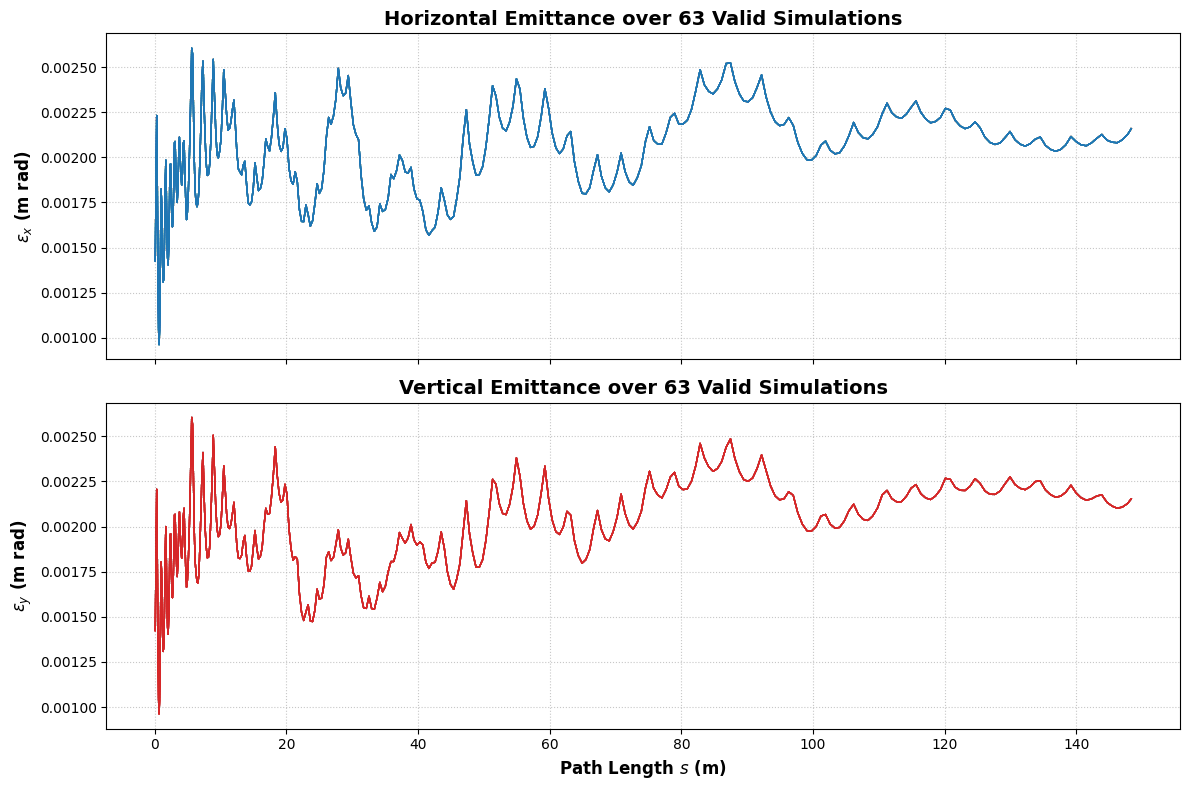

In [30]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def parse_stat_file(stat_file):
    """Parses an OPAL .stat file to extract s, eps_x, and eps_y."""
    col_names = []
    in_column = False
    
    with open(stat_file, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        line_stripped = line.strip()
        if line_stripped.startswith('&column'):
            in_column = True
        elif in_column and line_stripped.startswith('name='):
            name = line_stripped.split('=')[1].strip(',"\'').lower()
            col_names.append(name)
        elif line_stripped.startswith('&end') and in_column:
            in_column = False

    expected_cols = len(col_names)
    if expected_cols == 0:
        return None, None, None

    try:
        idx_s = col_names.index('s')
        idx_eps_x = col_names.index('rms_x')
        idx_eps_y = col_names.index('rms_y')
    except ValueError:
        return None, None, None

    s_vals, eps_x_vals, eps_y_vals = [], [], []
    
    for line in lines:
        parts = line.split()
        if len(parts) == expected_cols:
            try:
                row_floats = [float(x) for x in parts]
                s_vals.append(row_floats[idx_s])
                eps_x_vals.append(row_floats[idx_eps_x])
                eps_y_vals.append(row_floats[idx_eps_y])
            except ValueError:
                pass

    return s_vals, eps_x_vals, eps_y_vals

def plot_all_simulations(base_dir="/home/vagrant/jupyter/github/rsnewton/studies/rsopt_failures/ensemble/"):
    """Traverses worker/sim directories and plots all valid .stat files."""
    
    # 1. Find all .stat files in the archive structure
    search_pattern = os.path.join(base_dir, "worker*", "sim*", "*.stat")
    stat_files = glob.glob(search_pattern)
    
    # Sort files to ensure logical progression if you want to apply colormaps later
    stat_files.sort()
    
    if not stat_files:
        print("No .stat files found in the worker*/sim* directories.")
        return

    print(f"Found {len(stat_files)} simulation files. Processing...")

    # 2. Setup the figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    valid_runs = 0

    # 3. Loop through and plot each file
    for stat_file in stat_files:
        s, eps_x, eps_y = parse_stat_file(stat_file)
        
        # Skip incomplete or crashed simulations
        if s is None or len(s) < 2:
            continue
            
        valid_runs += 1
        
        # Plot with low alpha to see the density of the optimization
        ax1.plot(s, eps_x, color='#1f77b4', alpha=0.1, linewidth=1)
        ax2.plot(s, eps_y, color='#d62728', alpha=0.1, linewidth=1)

    if valid_runs == 0:
        print("None of the files contained valid tracking data (did OPAL crash on all of them?).")
        return

    # 4. Format the plot
    ax1.set_ylabel(r'$\epsilon_x$ (m rad)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Horizontal Emittance over {valid_runs} Valid Simulations', fontsize=14, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.7)

    ax2.set_xlabel('Path Length $s$ (m)', fontsize=12, fontweight='bold')
    ax2.set_ylabel(r'$\epsilon_y$ (m rad)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Vertical Emittance over {valid_runs} Valid Simulations', fontsize=14, fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    output_filename = 'archive_emittance_spread.png'
    plt.savefig(output_filename, dpi=300)
    print(f"Plot saved successfully as '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    plot_all_simulations()

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_downstream_effects(csv_file='cavity_failure_catalog.csv', metric='Total_Lost'):
    """
    Reads the 1D cavity failure catalog and extrapolates it into a 2D 
    spatial matrix showing how failures propagate downstream.
    """
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"Error: Could not find '{csv_file}'.")
        return

    # Filter for successful OPAL runs and sort logically (CAV001, CAV002, etc.)
    df = df[df['Status'] == 'SUCCESS'].copy()
    df = df.sort_values('Broken_Cavity').reset_index(drop=True)
    
    if df.empty:
        print("No successful simulations found in the catalog.")
        return

    cavities = df['Broken_Cavity'].tolist()
    n = len(cavities)

    # Initialize an NxN matrix
    matrix = np.zeros((n, n))

    for col_idx, row in df.iterrows():
        val = pd.to_numeric(row[metric], errors='coerce')
        if pd.isna(val):
            val = 0
            
        failed_cavity_idx = col_idx
        
        # Propagate the effect downstream
        for observation_idx in range(n):
            if observation_idx >= failed_cavity_idx:
                matrix[observation_idx, failed_cavity_idx] = val
            else:
                matrix[observation_idx, failed_cavity_idx] = 0

    # Create a mask to hide the impossible physics (the upper triangle)
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

    # Dynamically adjust formatting based on the metric
    if 'Emit' in metric or 'Eps' in metric:
        annot_fmt = ".2e"     # Scientific notation for tiny emittances
        cmap_choice = "viridis" # Distinct color scheme for emittance
    else:
        annot_fmt = ".0f"     # Integers for particle loss
        cmap_choice = "Reds"    # Danger color for lost particles

    # Plotting
    plt.figure(figsize=(10, 8))

#    sns.heatmap(
#        matrix, 
#        mask=mask, 
#        cmap=cmap_choice, 
#        annot=True, 
#        fmt=annot_fmt, 
#        square=True, 
#        linewidths=1.0, 
#       xticklabels=cavities,
#        yticklabels=cavities,
#        cbar_kws={"shrink": .8, "label": f"{metric.replace('_', ' ')}"}
#    )

    plt.imshow(matrix.T)
    
    plt.title(f'Downstream Propagation: {metric.replace("_", " ")}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Failed Cavity', fontsize=12, fontweight='bold')
    plt.ylabel('Observation Location', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    output_filename = f'downstream_matrix_{metric}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully saved plot to '{output_filename}'.")
    plt.close() # Close the figure to free memory before the next plot

if __name__ == "__main__":
    # Generate the Particle Loss Matrix
    plot_downstream_effects(metric='Total_Lost')
    
    # Generate the Emittance Growth Matrix
    plot_downstream_effects(metric='Emit_Sum')

Successfully saved plot to 'downstream_matrix_Total_Lost.png'.
Successfully saved plot to 'downstream_matrix_Emit_Sum.png'.


Parsing .stat files...
Plot successfully saved to 'linac_failure_sensitivity_map.png'


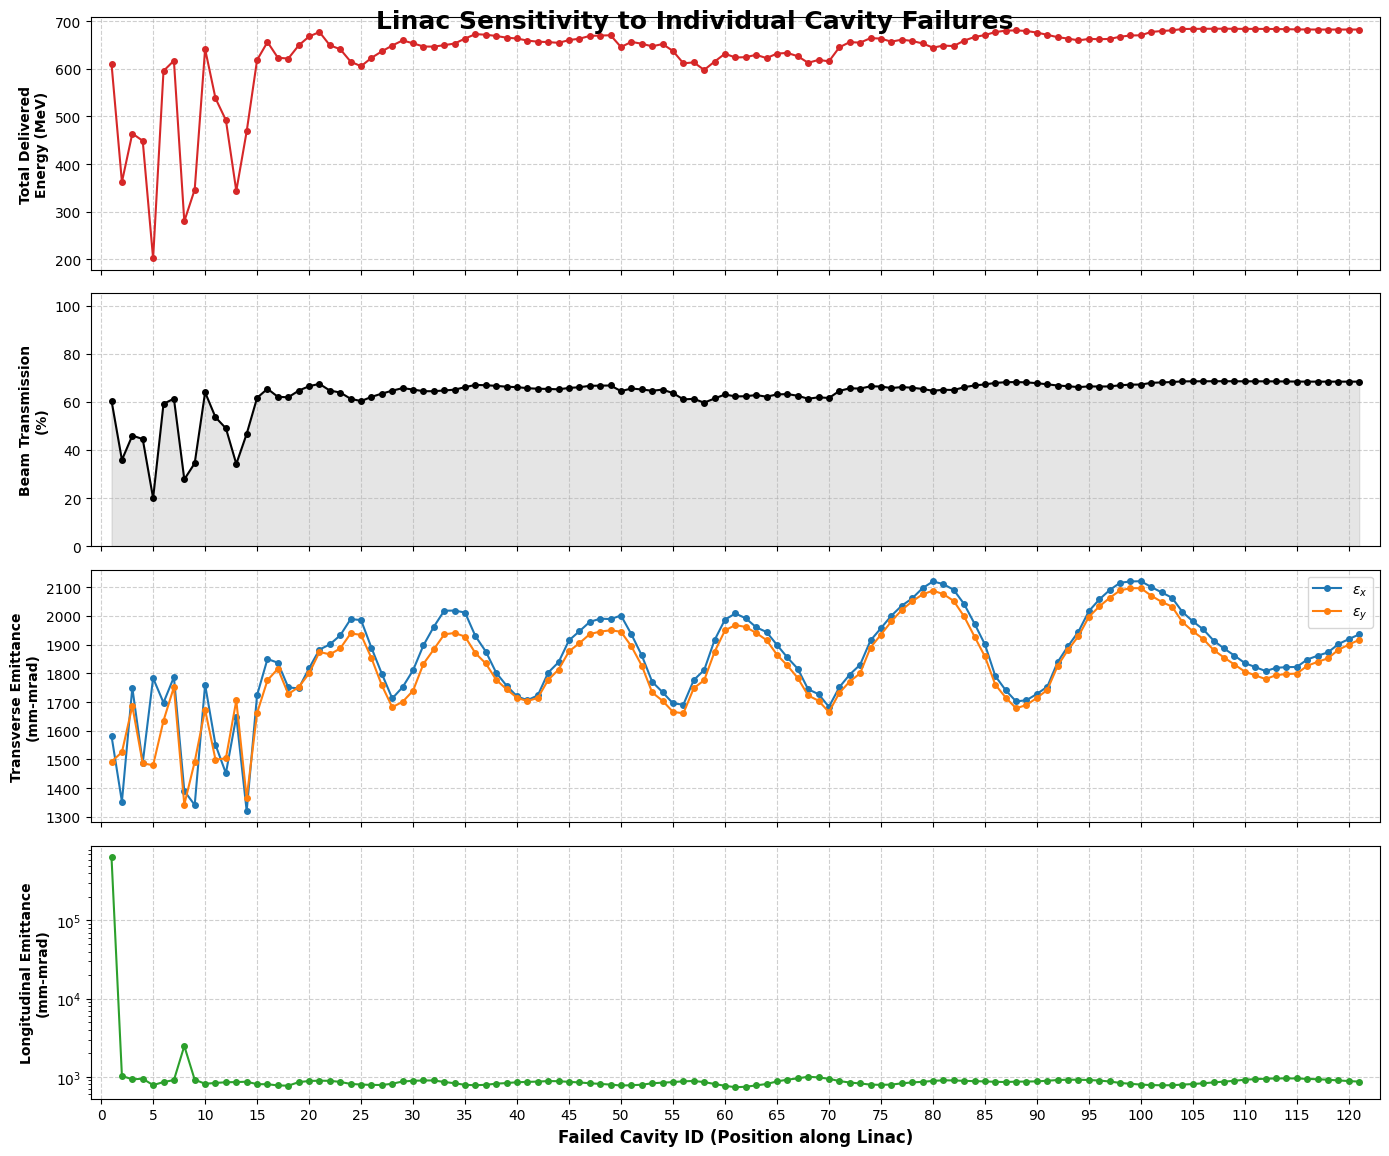

In [207]:
import os
import glob
import matplotlib.pyplot as plt

def plot_linac_sensitivity():
    stat_files = glob.glob("fail_CAV*.stat")
    if not stat_files:
        print("[!] No .stat files found in the current directory.")
        return

    # Data storage
    cavity_nums = []
    transported_energies = []
    transmissions = []
    final_eps_x = []
    final_eps_y = []
    final_eps_z = []

    print("Parsing .stat files...")

    for f in stat_files:
        # Extract integer cavity number (e.g., fail_CAV005.stat -> 5)
        try:
            cav_num = int(f.replace('fail_CAV', '').replace('.stat', ''))
        except ValueError:
            continue

        with open(f, 'r') as file:
            lines = file.readlines()

        col_names = []
        in_column = False
        for line in lines:
            line_stripped = line.strip()
            if line_stripped.startswith('&column'):
                in_column = True
            elif in_column and line_stripped.startswith('name='):
                name = line_stripped.split('=')[1].strip(',"\'').lower()
                col_names.append(name)
            elif line_stripped.startswith('&end') and in_column:
                in_column = False

        try:
            idx_s = col_names.index('s')
            idx_particles = col_names.index('numparticles')
            idx_energy = col_names.index('energy')
            idx_eps_x = col_names.index('rms_x')
            idx_eps_y = col_names.index('rms_y')
            idx_eps_z = col_names.index('rms_s')
        except ValueError:
            continue

        # Extract data rows
        expected_cols = len(col_names)
        data_rows = []
        for line in lines:
            parts = line.split()
            if len(parts) == expected_cols:
                try:
                    data_rows.append([float(x) for x in parts])
                except ValueError:
                    pass

        if not data_rows:
            continue

        initial_particles = data_rows[0][idx_particles]
        final_row = data_rows[-1]
        final_s = final_row[idx_s]

        # Check if the beam actually survived to the end (~148m)
        if final_s < 147.0:
            # Fatal crash: Nothing reached the end
            transmission = 0.0
            transported_energy = 0.0
            eps_x_val = None
            eps_y_val = None
            eps_z_val = None
        else:
            final_particles = final_row[idx_particles]
            final_energy = final_row[idx_energy]
            
            transmission = (final_particles / initial_particles) * 100
            transported_energy = final_energy * (final_particles / initial_particles)
            
            # Convert emittance to mm-mrad (or typical scaled units)
            eps_x_val = final_row[idx_eps_x] * 1e6
            eps_y_val = final_row[idx_eps_y] * 1e6
            eps_z_val = final_row[idx_eps_z] * 1e6

        cavity_nums.append(cav_num)
        transmissions.append(transmission)
        transported_energies.append(transported_energy)
        final_eps_x.append(eps_x_val)
        final_eps_y.append(eps_y_val)
        final_eps_z.append(eps_z_val)

    # Sort all data by cavity number
    sorted_indices = sorted(range(len(cavity_nums)), key=lambda k: cavity_nums[k])
    cavity_nums = [cavity_nums[i] for i in sorted_indices]
    transmissions = [transmissions[i] for i in sorted_indices]
    transported_energies = [transported_energies[i] for i in sorted_indices]
    final_eps_x = [final_eps_x[i] for i in sorted_indices]
    final_eps_y = [final_eps_y[i] for i in sorted_indices]
    final_eps_z = [final_eps_z[i] for i in sorted_indices]

    # --- Setup the 4-Panel Master Plot ---
    fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Linac Sensitivity to Individual Cavity Failures', fontsize=18, fontweight='bold', y=0.96)

    # 1. Total Transported Energy
    axs[0].plot(cavity_nums, transported_energies, marker='o', color='#d62728', linestyle='-', linewidth=1.5, markersize=4)
    axs[0].set_ylabel('Total Delivered\nEnergy (MeV)', fontweight='bold')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Particle Loss / Transmission
    axs[1].plot(cavity_nums, transmissions, marker='o', color='black', linestyle='-', linewidth=1.5, markersize=4)
    axs[1].fill_between(cavity_nums, 0, transmissions, color='gray', alpha=0.2)
    axs[1].set_ylabel('Beam Transmission\n(%)', fontweight='bold')
    axs[1].set_ylim(0, 105)
    axs[1].grid(True, linestyle='--', alpha=0.6)

    # 3. Transverse Emittance
    axs[2].plot(cavity_nums, final_eps_x, label=r'$\epsilon_x$', marker='o', color='#1f77b4', linestyle='-', markersize=4)
    axs[2].plot(cavity_nums, final_eps_y, label=r'$\epsilon_y$', marker='o', color='#ff7f0e', linestyle='-', markersize=4)
    axs[2].set_ylabel('Transverse Emittance\n(mm-mrad)', fontweight='bold')
    axs[2].legend(loc='upper right')
    axs[2].grid(True, linestyle='--', alpha=0.6)

    # 4. Longitudinal Emittance
    axs[3].plot(cavity_nums, final_eps_z, marker='o', color='#2ca02c', linestyle='-', linewidth=1.5, markersize=4)
    axs[3].set_ylabel('Longitudinal Emittance\n(mm-mrad)', fontweight='bold')
    axs[3].set_xlabel('Failed Cavity ID (Position along Linac)', fontweight='bold', fontsize=12)
    axs[3].grid(True, linestyle='--', alpha=0.6)

    # Clean up X-axis ticks to show cavity numbers nicely
    axs[3].set_xticks(range(0, max(cavity_nums) + 5, 5))
    axs[3].set_xlim(min(cavity_nums) - 2, max(cavity_nums) + 2)
    axs[3].set_yscale('log')
    plt.tight_layout()
    output_filename = 'linac_failure_sensitivity_map.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Plot successfully saved to '{output_filename}'")
    plt.show()

if __name__ == "__main__":
    plot_linac_sensitivity()

<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:60: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_26542/2520767541.py:59: SyntaxWarning: invalid escape sequence '\D'
  labels = {'x': ('$\Delta x$ (mm)', '$\Delta p_x$'),
/tmp/ipykernel_26542/2520767541.py:59: SyntaxWarning: invalid escape sequence '\D'
  labels = {'x': ('$\Delta x$ (mm)', '$\Delta p_x$'),
/tmp/ipykernel_26542/2520767541.py:60: SyntaxWarning: invalid escape sequence '\D'
  'y': ('$\Delta y$ (mm)', '$\D

Successfully saved plot to 'master_phase_space_CAV023.png'.


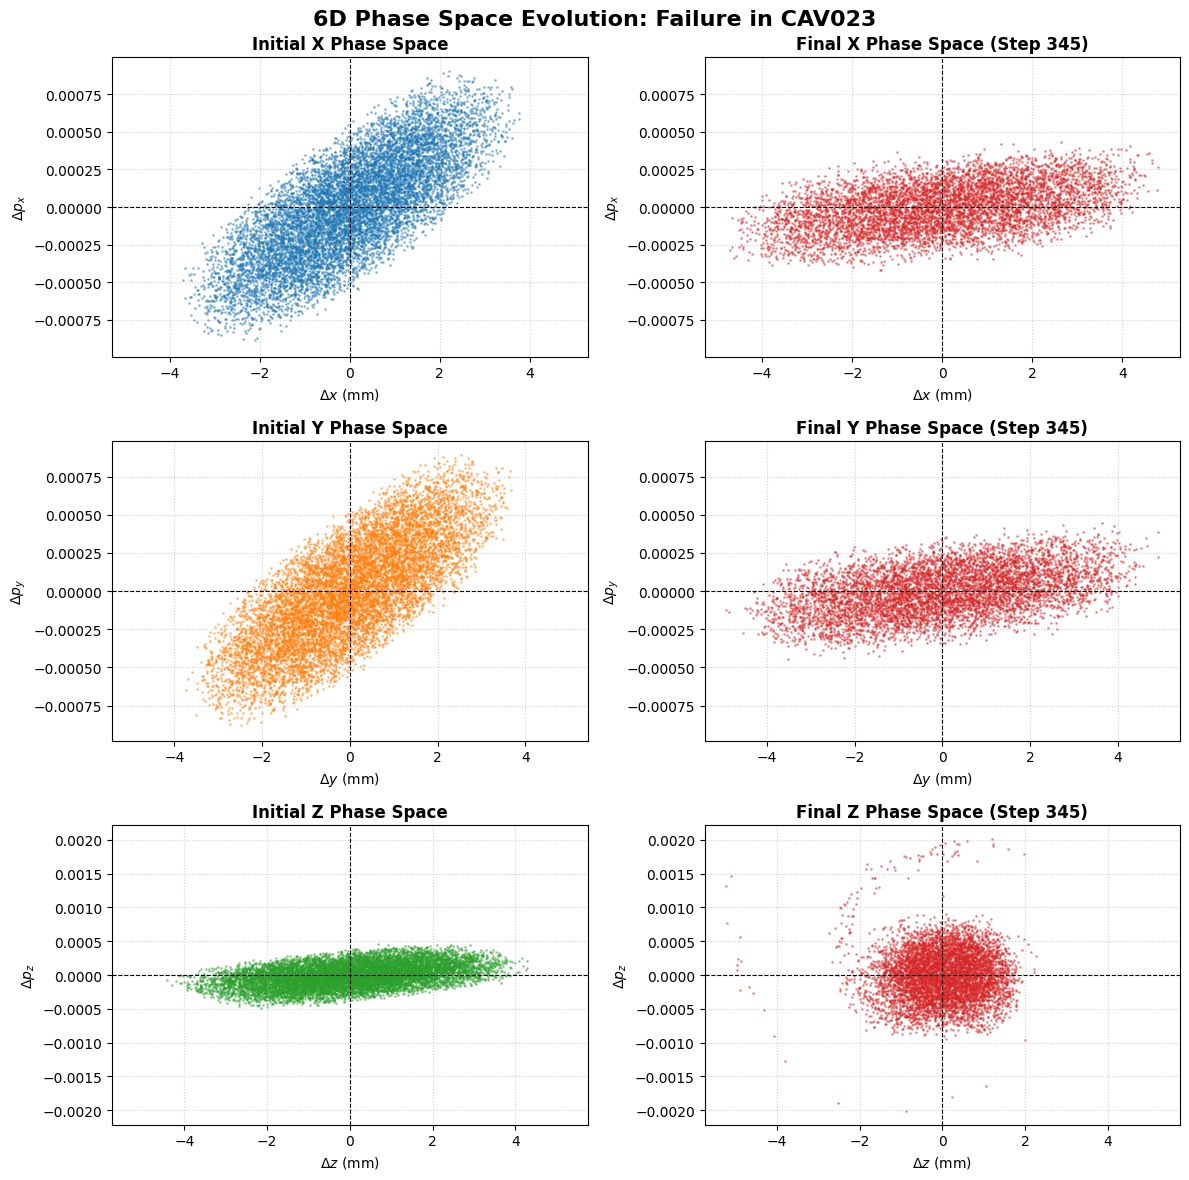

In [171]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def plot_master_phase_space_shared_scale(cav_num=23):
    filename = f"fail_CAV{cav_num:03d}.h5"

    if not os.path.exists(filename):
        print(f"[!] Cannot find '{filename}'. Did you run with psdumpfreq > 0?")
        return

    try:
        with h5py.File(filename, 'r') as h5_file:
            step_keys = [key for key in h5_file.keys() if key.startswith('Step#')]
            if not step_keys:
                print(f"[!] No step data found in '{filename}'.")
                return
            
            step_keys.sort(key=lambda x: int(x.split('#')[1]))
            first_step = step_keys[0]
            last_step = step_keys[-1]

            if len(step_keys) == 1:
                print(f"[!] WARNING: Only {first_step} exists. The beam likely crashed before the next dump.")
                return

            # Extract raw coordinates
            data = {}
            for step, prefix in zip([first_step, last_step], ['init', 'final']):
                for dim in ['x', 'y', 'z', 'px', 'py', 'pz']:
                    data[f'{dim}_{prefix}'] = h5_file[step][dim][:]
            
            final_step_num = last_step.split('#')[1]

    except Exception as e:
        print(f"[!] Error reading HDF5 file: {e}")
        return

    # Center all dimensions and convert spatial coordinates to millimeters
    plot_data = {}
    for prefix in ['init', 'final']:
        plot_data[f'dx_{prefix}'] = (data[f'x_{prefix}'] - np.mean(data[f'x_{prefix}'])) * 1000
        plot_data[f'dpx_{prefix}'] = data[f'px_{prefix}'] - np.mean(data[f'px_{prefix}'])
        
        plot_data[f'dy_{prefix}'] = (data[f'y_{prefix}'] - np.mean(data[f'y_{prefix}'])) * 1000
        plot_data[f'dpy_{prefix}'] = data[f'py_{prefix}'] - np.mean(data[f'py_{prefix}'])
        
        plot_data[f'dz_{prefix}'] = (data[f'z_{prefix}'] - np.mean(data[f'z_{prefix}'])) * 1000
        plot_data[f'dpz_{prefix}'] = data[f'pz_{prefix}'] - np.mean(data[f'pz_{prefix}'])

    # Setup the 3x2 Plot
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    fig.suptitle(f'6D Phase Space Evolution: Failure in CAV{cav_num:03d}', fontsize=16, fontweight='bold', y=0.98)

    # Style definitions
    scatter_kwargs = {'s': 1, 'alpha': 0.4}
    colors = {'x': '#1f77b4', 'y': '#ff7f0e', 'z': '#2ca02c', 'final': '#d62728'}
    labels = {'x': ('$\Delta x$ (mm)', '$\Delta p_x$'), 
              'y': ('$\Delta y$ (mm)', '$\Delta p_y$'), 
              'z': ('$\Delta z$ (mm)', '$\Delta p_z$')}

    dims = ['x', 'y', 'z']
    
    for row, dim in enumerate(dims):
        # Plot Initial (Left Column)
        axs[row, 0].scatter(plot_data[f'd{dim}_init'], plot_data[f'dp{dim}_init'], color=colors[dim], **scatter_kwargs)
        axs[row, 0].set_title(f'Initial {dim.upper()} Phase Space', fontweight='bold')
        axs[row, 0].set_xlabel(labels[dim][0])
        axs[row, 0].set_ylabel(labels[dim][1])

        # Plot Final (Right Column)
        axs[row, 1].scatter(plot_data[f'd{dim}_final'], plot_data[f'dp{dim}_final'], color=colors['final'], **scatter_kwargs)
        axs[row, 1].set_title(f'Final {dim.upper()} Phase Space (Step {final_step_num})', fontweight='bold')
        axs[row, 1].set_xlabel(labels[dim][0])
        axs[row, 1].set_ylabel(labels[dim][1])

        # --- Calculate Shared Scale ---
        # Find the absolute maximum value across BOTH initial and final distributions
        max_spatial = max(np.max(np.abs(plot_data[f'd{dim}_init'])), np.max(np.abs(plot_data[f'd{dim}_final'])))
        max_momentum = max(np.max(np.abs(plot_data[f'dp{dim}_init'])), np.max(np.abs(plot_data[f'dp{dim}_final'])))
        
        # Add a 10% margin so particles don't sit exactly on the axis borders
        xlims = (-max_spatial * 1.1, max_spatial * 1.1)
        ylims = (-max_momentum * 1.1, max_momentum * 1.1)

        # Apply identical limits, grid, and center lines to both columns
        for col in [0, 1]:
            axs[row, col].set_xlim(xlims)
            axs[row, col].set_ylim(ylims)
            axs[row, col].axhline(0, color='black', linewidth=0.8, linestyle='--')
            axs[row, col].axvline(0, color='black', linewidth=0.8, linestyle='--')
            axs[row, col].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    output_filename = f'master_phase_space_CAV{cav_num:03d}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully saved plot to '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    plot_master_phase_space_shared_scale()


=== Particle Survival Summary for CAV025 ===
Unoptimized Failure: Lost 3971 / 10001 particles (39.7%)
BOBYQA Optimized:    Lost 3243 / 10001 particles (32.4%)

Successfully saved phase space comparison to 'optimization_comparison_CAV025.png'.


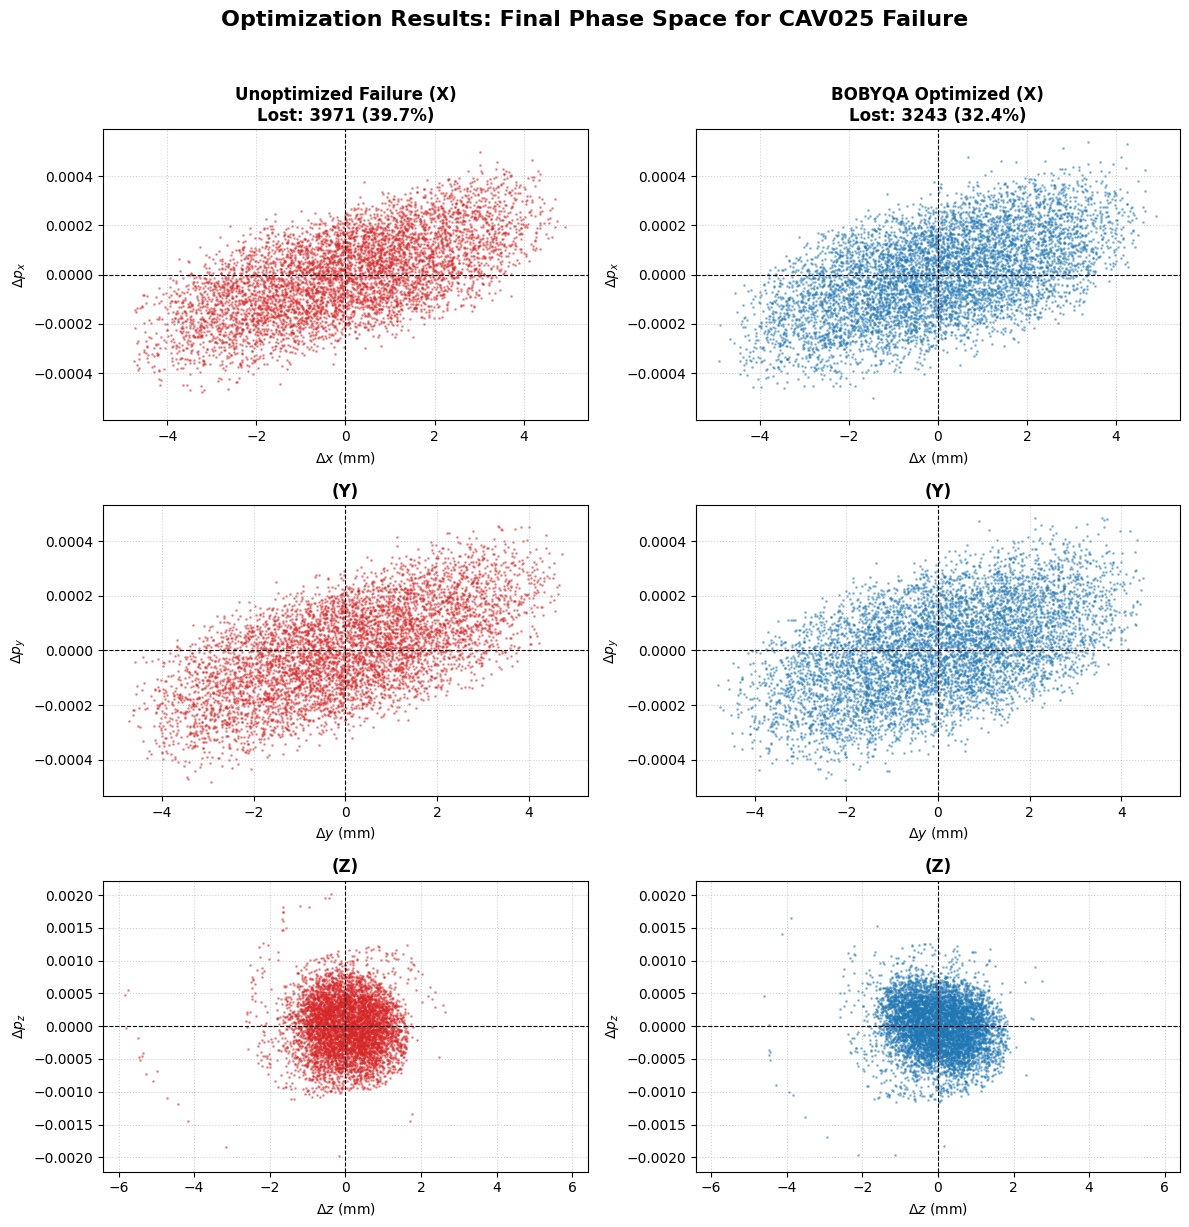

In [323]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def compare_optimized_phase_spaces(cav_num=25):

    file_unopt = f"initial_CAV{cav_num:03d}.h5"
    file_opt = f"optimal_CAV{cav_num:03d}.h5"

    if not os.path.exists(file_unopt) or not os.path.exists(file_opt):
        print(f"[!] Error: Missing HDF5 files. Ensure both '{file_unopt}' and '{file_opt}' exist.")
        return

    data = {}
    
    try:
        # --- Unoptimized (Initial) Run ---
        with h5py.File(file_unopt, 'r') as h5_unopt:
            steps_unopt = [k for k in h5_unopt.keys() if k.startswith('Step#')]
            steps_unopt.sort(key=lambda x: int(x.split('#')[1]))
            first_step_unopt = steps_unopt[0]
            last_step_unopt = steps_unopt[-1]
            
            # Calculate particle loss
            initial_particles_unopt = len(h5_unopt[first_step_unopt]['x'][:])
            final_particles_unopt = len(h5_unopt[last_step_unopt]['x'][:])
            lost_unopt = initial_particles_unopt - final_particles_unopt
            
            for dim in ['x', 'y', 'z', 'px', 'py', 'pz']:
                data[f'{dim}_unopt'] = h5_unopt[last_step_unopt][dim][:]

        # --- Optimized Run ---
        with h5py.File(file_opt, 'r') as h5_opt:
            steps_opt = [k for k in h5_opt.keys() if k.startswith('Step#')]
            steps_opt.sort(key=lambda x: int(x.split('#')[1]))
            first_step_opt = steps_opt[0]
            last_step_opt = steps_opt[-1]
            
            # Calculate particle loss
            initial_particles_opt = len(h5_opt[first_step_opt]['x'][:])
            final_particles_opt = len(h5_opt[last_step_opt]['x'][:])
            lost_opt = initial_particles_opt - final_particles_opt
            
            for dim in ['x', 'y', 'z', 'px', 'py', 'pz']:
                data[f'{dim}_opt'] = h5_opt[last_step_opt][dim][:]

    except Exception as e:
        print(f"[!] Error reading HDF5 files: {e}")
        return

    # --- Print Statistics to Console ---
    print(f"\n=== Particle Survival Summary for CAV{cav_num:03d} ===")
    print(f"Unoptimized Failure: Lost {lost_unopt} / {initial_particles_unopt} particles "
          f"({(lost_unopt/initial_particles_unopt)*100:.1f}%)")
    print(f"BOBYQA Optimized:    Lost {lost_opt} / {initial_particles_opt} particles "
          f"({(lost_opt/initial_particles_opt)*100:.1f}%)\n")

    # Center coordinates and convert spatial dimensions to millimeters
    plot_data = {}
    for condition in ['unopt', 'opt']:
        plot_data[f'dx_{condition}'] = (data[f'x_{condition}'] - np.mean(data[f'x_{condition}'])) * 1000
        plot_data[f'dpx_{condition}'] = data[f'px_{condition}'] - np.mean(data[f'px_{condition}'])
        
        plot_data[f'dy_{condition}'] = (data[f'y_{condition}'] - np.mean(data[f'y_{condition}'])) * 1000
        plot_data[f'dpy_{condition}'] = data[f'py_{condition}'] - np.mean(data[f'py_{condition}'])
        
        plot_data[f'dz_{condition}'] = (data[f'z_{condition}'] - np.mean(data[f'z_{condition}'])) * 1000
        plot_data[f'dpz_{condition}'] = data[f'pz_{condition}'] - np.mean(data[f'pz_{condition}'])

    # Setup the 3x2 Plot Grid
    fig, axs = plt.subplots(3, 2, figsize=(12, 13))
    fig.suptitle(f'Optimization Results: Final Phase Space for CAV{cav_num:03d} Failure', 
                 fontsize=16, fontweight='bold', y=0.97)

    scatter_kwargs = {'s': 1, 'alpha': 0.4}
    color_unopt = '#d62728'  
    color_opt = '#1f77b4'    

    labels = {
        'x': (r'$\Delta x$ (mm)', r'$\Delta p_x$'), 
        'y': (r'$\Delta y$ (mm)', r'$\Delta p_y$'), 
        'z': (r'$\Delta z$ (mm)', r'$\Delta p_z$')
    }

    for row, dim in enumerate(['x', 'y', 'z']):
        # Left Column: Unoptimized
        axs[row, 0].scatter(plot_data[f'd{dim}_unopt'], plot_data[f'dp{dim}_unopt'], 
                            color=color_unopt, **scatter_kwargs)
        axs[row, 0].set_xlabel(labels[dim][0])
        axs[row, 0].set_ylabel(labels[dim][1])

        # Right Column: Optimized
        axs[row, 1].scatter(plot_data[f'd{dim}_opt'], plot_data[f'dp{dim}_opt'], 
                            color=color_opt, **scatter_kwargs)
        axs[row, 1].set_xlabel(labels[dim][0])
        axs[row, 1].set_ylabel(labels[dim][1])

        # Add titles only to the top row to act as column headers
        if row == 0:
            axs[row, 0].set_title(f"Unoptimized Failure ({dim.upper()})\n"
                                  f"Lost: {lost_unopt} ({(lost_unopt/initial_particles_unopt)*100:.1f}%)", 
                                  fontweight='bold')
            axs[row, 1].set_title(f"BOBYQA Optimized ({dim.upper()})\n"
                                  f"Lost: {lost_opt} ({(lost_opt/initial_particles_opt)*100:.1f}%)", 
                                  fontweight='bold')
        else:
            axs[row, 0].set_title(f"({dim.upper()})", fontweight='bold')
            axs[row, 1].set_title(f"({dim.upper()})", fontweight='bold')

        # --- Enforce Identical Scales for Direct Visual Comparison ---
        max_spatial = max(np.max(np.abs(plot_data[f'd{dim}_unopt'])), np.max(np.abs(plot_data[f'd{dim}_opt'])))
        max_momentum = max(np.max(np.abs(plot_data[f'dp{dim}_unopt'])), np.max(np.abs(plot_data[f'dp{dim}_opt'])))
        
        xlims = (-max_spatial * 1.1, max_spatial * 1.1)
        ylims = (-max_momentum * 1.1, max_momentum * 1.1)

        for col in [0, 1]:
            axs[row, col].set_xlim(xlims)
            axs[row, col].set_ylim(ylims)
            axs[row, col].axhline(0, color='black', linewidth=0.8, linestyle='--')
            axs[row, col].axvline(0, color='black', linewidth=0.8, linestyle='--')
            axs[row, col].grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    output_filename = f'optimization_comparison_CAV{cav_num:03d}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully saved phase space comparison to '{output_filename}'.")
    plt.show()

if __name__ == "__main__":
    compare_optimized_phase_spaces()

In [332]:
import os

def print_emittance_comparison(cav_num):
    
    file_unopt = f"initial_CAV{cav_num:03d}.stat"
    file_opt = f"optimal_CAV{cav_num:03d}.stat"

    if not os.path.exists(file_unopt) or not os.path.exists(file_opt):
        print(f"[!] Error: Missing .stat files. Ensure both '{file_unopt}' and '{file_opt}' exist.")
        return

    def extract_final_emittance(stat_file):
        with open(stat_file, 'r') as file:
            lines = file.readlines()

        col_names = []
        in_column = False
        for line in lines:
            line_stripped = line.strip()
            if line_stripped.startswith('&column'):
                in_column = True
            elif in_column and line_stripped.startswith('name='):
                col_names.append(line_stripped.split('=')[1].strip(',"\'').lower())
            elif line_stripped.startswith('&end') and in_column:
                in_column = False

        try:
            idx_eps_x = col_names.index('rms_x')
            idx_eps_y = col_names.index('rms_y')
            idx_eps_z = col_names.index('rms_s')
        except ValueError:
            return None

        # Extract data rows
        expected_cols = len(col_names)
        data_rows = [[float(x) for x in line.split()] for line in lines if len(line.split()) == expected_cols]
        
        if not data_rows:
            return None

        # Grab the absolute last step recorded in the file
        final_row = data_rows[-1]
        
        # Scale to mm-mrad for readability
        return {
            'x': final_row[idx_eps_x] * 1e6,
            'y': final_row[idx_eps_y] * 1e6,
            'z': final_row[idx_eps_z] * 1e6
        }

    emit_unopt = extract_final_emittance(file_unopt)
    emit_opt = extract_final_emittance(file_opt)

    if emit_unopt is None or emit_opt is None:
        print(f"[!] Failed to parse emittance from one or both .stat files.")
        return

    # Print the comparison table
    print(f"\n=== Final Emittance Comparison for CAV{cav_num:03d} (mm-mrad) ===")
    print(f"{'Plane':<8} | {'Unoptimized':<14} | {'Optimized':<14} | {'Change':<15}")
    print("-" * 57)
    
    for plane in ['x', 'y', 'z']:
        val_unopt = emit_unopt[plane]
        val_opt = emit_opt[plane]
        
        # Calculate percentage change (negative is better for emittance)
        diff = val_opt - val_unopt
        pct_change = (diff / val_unopt) * 100 if val_unopt != 0 else 0
        
        #trend = "Improved" if diff < 0 else "Worse"
        
        #print(f"{plane.upper():<8} | {val_unopt:<14.4f} | {val_opt:<14.4f} | {pct_change:+.1f}% ({trend})")
        print(f"{plane.upper():<8} | {val_unopt:<14.4f} | {val_opt:<14.4f} | {pct_change:+.1f}% ")
    print("-" * 57)
    #print("Note: Values are normalized emittance, extracted from the final tracking step.\n")

if __name__ == "__main__":
    print_emittance_comparison(25)


=== Final Emittance Comparison for CAV025 (mm-mrad) ===
Plane    | Unoptimized    | Optimized      | Change         
---------------------------------------------------------
X        | 1985.6621      | 1924.4152      | -3.1% 
Y        | 1934.2626      | 1860.0680      | -3.8% 
Z        | 799.0776       | 810.2106       | +1.4% 
---------------------------------------------------------


# Comparing the results of all optimizations 

Parsing data for 55 cavities...
Successfully generated summary plot: 'optimization_impact_summary.png'


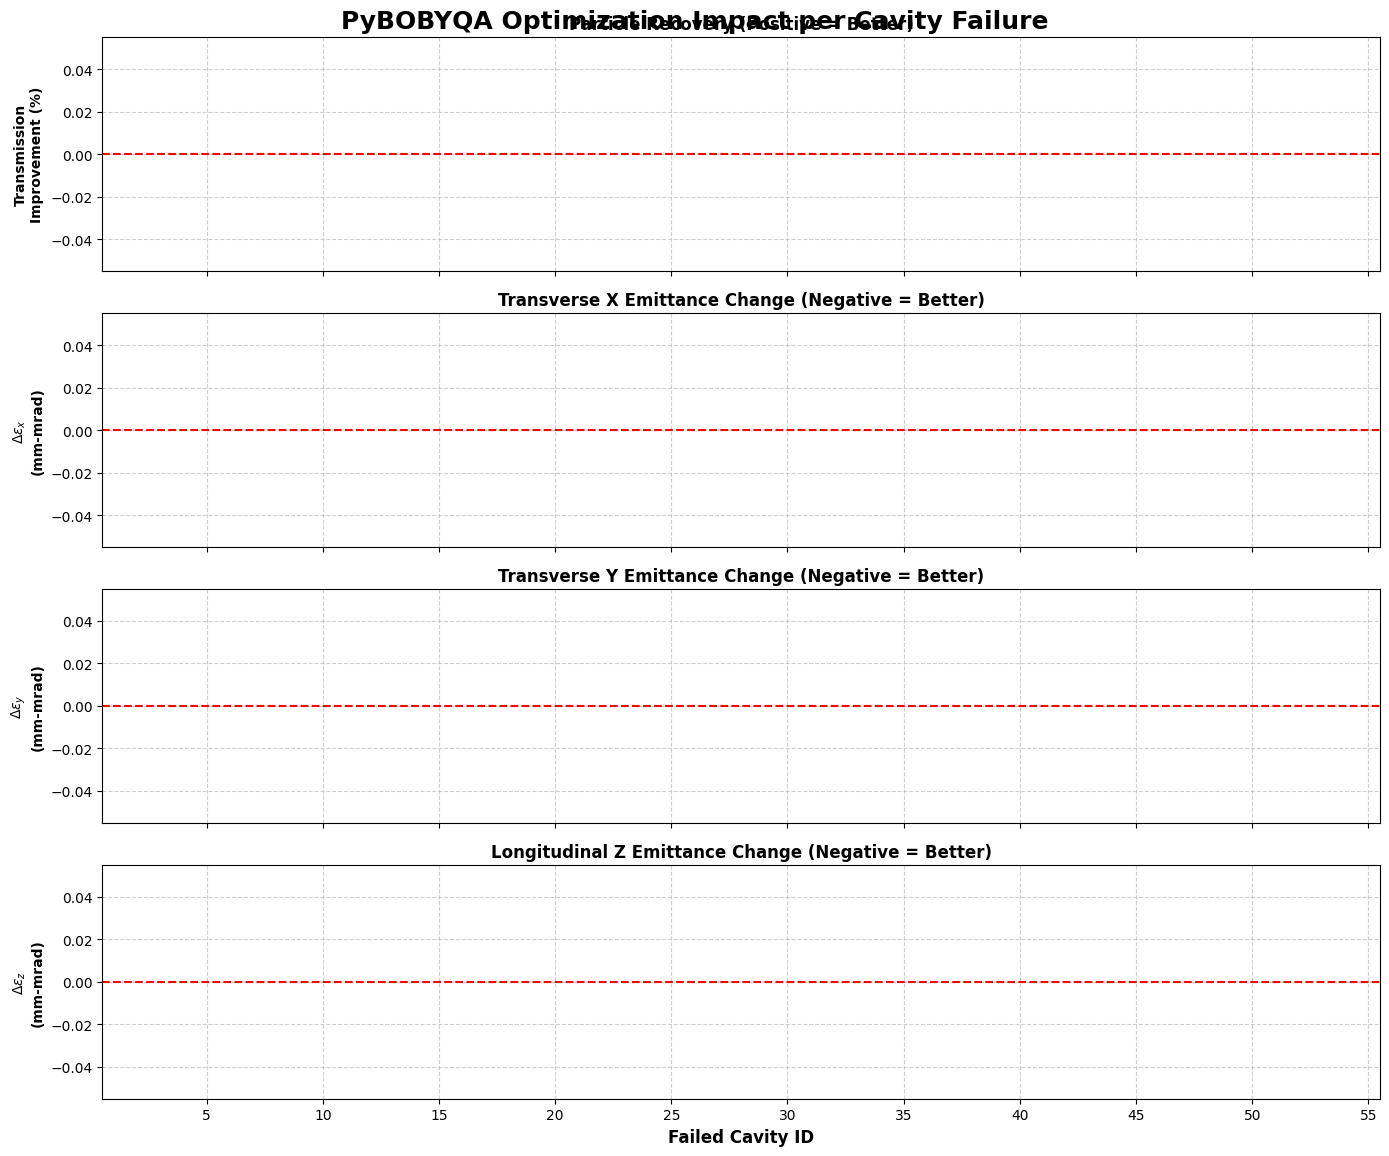

In [335]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_stat_file(filepath):
    """Parses a .stat file and returns final transmission (%) and scaled emittances."""
    if not os.path.exists(filepath):
        return None

    with open(filepath, 'r') as file:
        lines = file.readlines()

    col_names = []
    in_column = False
    for line in lines:
        line_stripped = line.strip()
        if line_stripped.startswith('&column'):
            in_column = True
        elif in_column and line_stripped.startswith('name='):
            col_names.append(line_stripped.split('=')[1].strip(',"\'').lower())
        elif line_stripped.startswith('&end') and in_column:
            in_column = False

    try:
        idx_s = col_names.index('s')
        idx_particles = col_names.index('numparticles')
        idx_eps_x = col_names.index('eps_x')
        idx_eps_y = col_names.index('eps_y')
        idx_eps_z = col_names.index('eps_z')
    except ValueError:
        return None

    data_rows = [[float(x) for x in line.split()] for line in lines if len(line.split()) == len(col_names)]
    if not data_rows:
        return None

    initial_particles = data_rows[0][idx_particles]
    final_row = data_rows[-1]
    final_s = final_row[idx_s]

    # Check if beam crashed before the end of the linac (assuming ~148m)
    if final_s < 147.0:
        return {'transmission': 0.0, 'eps_x': 0.0, 'eps_y': 0.0, 'eps_z': 0.0}

    return {
        'transmission': (final_row[idx_particles] / initial_particles) * 100.0,
        'eps_x': final_row[idx_eps_x] * 1e6,
        'eps_y': final_row[idx_eps_y] * 1e6,
        'eps_z': final_row[idx_eps_z] * 1e6
    }

def plot_optimization_impact():
    # Find all relevant .stat files to determine the max cavity number
    all_files = glob.glob("initial_CAV*.stat") + glob.glob("optimal_CAV*.stat")
    if not all_files:
        print("[!] No initial or optimal .stat files found in the current directory.")
        return

    cavity_nums = set()
    for f in all_files:
        match = re.search(r'CAV(\d+)\.stat', f)
        if match:
            cavity_nums.add(int(match.group(1)))

    max_cav = max(cavity_nums) if cavity_nums else 0

    cavities = []
    delta_trans = []
    delta_eps_x = []
    delta_eps_y = []
    delta_eps_z = []

    print(f"Parsing data for {max_cav} cavities...")

    for cav in range(1, max_cav + 1):
        init_data = parse_stat_file(f"initial_CAV{cav:03d}.stat")
        opt_data = parse_stat_file(f"optimal_CAV{cav:03d}.stat")

        cavities.append(cav)

        # Default to 0 change if either file is missing or corrupted
        if init_data is None or opt_data is None:
            delta_trans.append(0.0)
            delta_eps_x.append(0.0)
            delta_eps_y.append(0.0)
            delta_eps_z.append(0.0)
        else:
            # Improvement in Transmission (Positive is better)
            delta_trans.append(opt_data['transmission'] - init_data['transmission'])
            
            # Change in Emittance (Negative is better, meaning emittance shrank)
            # If the initial run crashed (trans=0), the emittance "improvement" is technically invalid, 
            # so we zero it out to avoid wild graph spikes.
            if init_data['transmission'] == 0:
                delta_eps_x.append(0.0)
                delta_eps_y.append(0.0)
                delta_eps_z.append(0.0)
            else:
                delta_eps_x.append(opt_data['eps_x'] - init_data['eps_x'])
                delta_eps_y.append(opt_data['eps_y'] - init_data['eps_y'])
                delta_eps_z.append(opt_data['eps_z'] - init_data['eps_z'])

    # --- Setup the 4-Panel Plot ---
    fig, axs = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('PyBOBYQA Optimization Impact per Cavity Failure', fontsize=18, fontweight='bold', y=0.96)

    # 1. Change in Transmission (Higher = More particles saved)
    axs[0].bar(cavities, delta_trans, color='black', alpha=0.7)
    axs[0].set_ylabel('Transmission\nImprovement (%)', fontweight='bold')
    axs[0].set_title('Particle Recovery (Positive = Better)', fontweight='bold')
    axs[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Change in X Emittance (Lower = Colder beam)
    axs[1].bar(cavities, delta_eps_x, color='#1f77b4', alpha=0.7)
    axs[1].set_ylabel(r'$\Delta \epsilon_x$'+'\n(mm-mrad)', fontweight='bold')
    axs[1].set_title('Transverse X Emittance Change (Negative = Better)', fontweight='bold')
    axs[1].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axs[1].grid(True, linestyle='--', alpha=0.6)

    # 3. Change in Y Emittance (Lower = Colder beam)
    axs[2].bar(cavities, delta_eps_y, color='#ff7f0e', alpha=0.7)
    axs[2].set_ylabel(r'$\Delta \epsilon_y$'+'\n(mm-mrad)', fontweight='bold')
    axs[2].set_title('Transverse Y Emittance Change (Negative = Better)', fontweight='bold')
    axs[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axs[2].grid(True, linestyle='--', alpha=0.6)

    # 4. Change in Z Emittance (Lower = Colder beam)
    axs[3].bar(cavities, delta_eps_z, color='#2ca02c', alpha=0.7)
    axs[3].set_ylabel(r'$\Delta \epsilon_z$'+'\n(mm-mrad)', fontweight='bold')
    axs[3].set_title('Longitudinal Z Emittance Change (Negative = Better)', fontweight='bold')
    axs[3].set_xlabel('Failed Cavity ID', fontweight='bold', fontsize=12)
    axs[3].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axs[3].grid(True, linestyle='--', alpha=0.6)

    # Clean up X-axis ticks
    axs[3].set_xticks(range(0, max_cav + 5, 5))
    axs[3].set_xlim(0.5, max_cav + 0.5)

    plt.tight_layout()
    output_filename = 'optimization_impact_summary.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Successfully generated summary plot: '{output_filename}'")
    plt.show()

if __name__ == "__main__":
    plot_optimization_impact()